In [60]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.25}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']

tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [61]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

In [62]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [64]:
# converged parameters for different protocol times 
protocol_times=[10,50,70,100,200]

pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()



building influence functional: 100%|██████████| 601/601 [1:30:47<00:00,  9.06s/it]  


rank  1953


KeyboardInterrupt: 

--> Compute dynamics:
100.0%   40 of   40 [########################################] 00:00:02
Elapsed time: 2.2s
--> Compute dynamics:
100.0%   40 of   40 [########################################] 00:00:02
Elapsed time: 2.2s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/1247475249.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


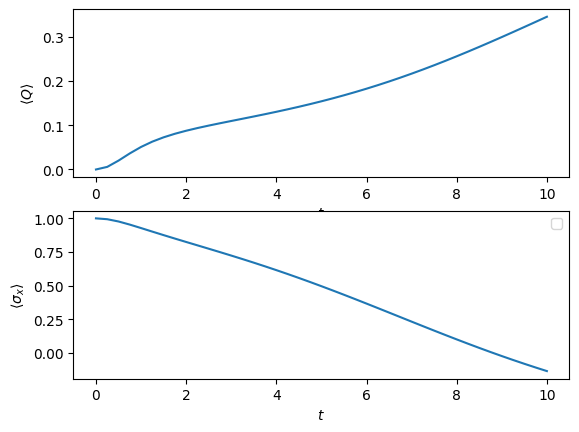

--> Compute dynamics:
100.0%  200 of  200 [########################################] 00:00:13
Elapsed time: 13.6s
--> Compute dynamics:
100.0%  200 of  200 [########################################] 00:00:12
Elapsed time: 12.5s


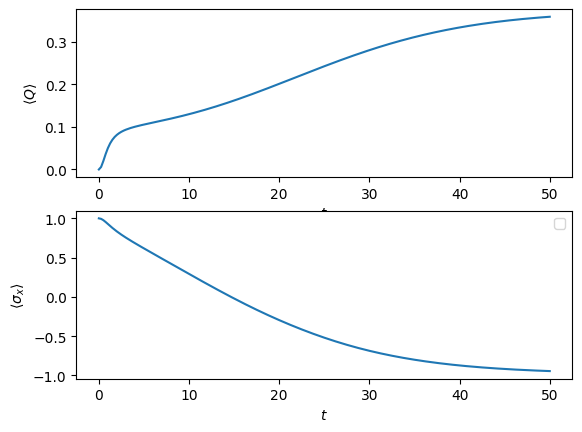

--> Compute dynamics:
100.0%  280 of  280 [########################################] 00:00:22
Elapsed time: 22.9s
--> Compute dynamics:
100.0%  280 of  280 [########################################] 00:00:17
Elapsed time: 17.1s


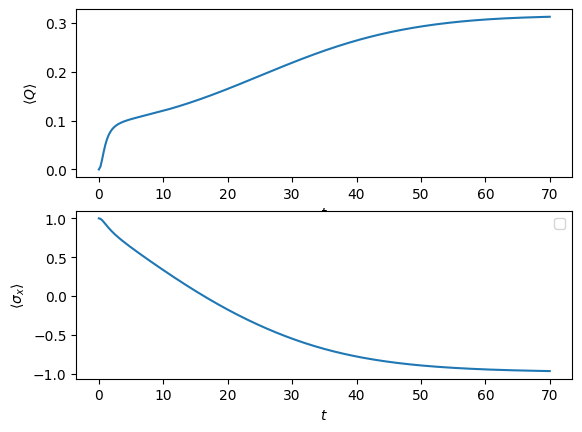

--> Compute dynamics:
100.0%  400 of  400 [########################################] 00:00:22
Elapsed time: 22.4s
--> Compute dynamics:
100.0%  400 of  400 [########################################] 00:00:22
Elapsed time: 22.3s


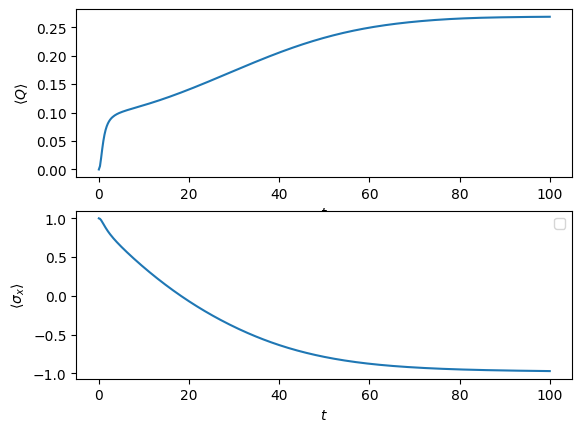

--> Compute dynamics:
100.0%  800 of  800 [########################################] 00:00:42
Elapsed time: 42.8s
--> Compute dynamics:
100.0%  800 of  800 [########################################] 00:00:48
Elapsed time: 48.2s


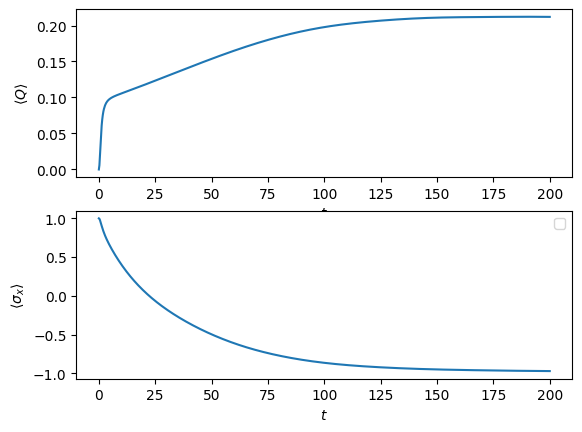

In [6]:

for t_prot in protocol_times:

   fig,axs=plt.subplots(2)

   num_steps=int(t_prot/dt)

   def hamiltonian_t(t):
      return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/t_prot)

   system = oqupy.TimeDependentSystem(hamiltonian_t)

   # compute dynamics

   dynamics=oqupy.compute_dynamics(
   process_tensor=process_tensor_var,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)
   t, s_x = dynamics.expectations(op.sigma('x'), real=True)

   # compute heats

   dynamicscf = oqupy.compute_dynamics(
   process_tensor=process_tensor_varcf,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)

   heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

   axs[0].plot(t,heats,label=t_prot)
   axs[0].set_xlabel(r'$t$')
   axs[0].set_ylabel(r'$\langle Q \rangle$')
   axs[1].plot(t,s_x)
   axs[1].set_xlabel(r'$t$')
   axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
   plt.legend()
   plt.show()


In [7]:
def discrete_hamiltonian(hx):
    return hx*op.sigma('x')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

target_derivative = -1j*np.identity(2)/u

In [8]:
# Cost Function
num_params=1

def heatandgrad(paras,process_tensor,num_steps):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    #parameter_list=np.array([item for pair in zip(paras[:num_steps],paras[num_steps:2*num_steps]) for item in pair])
    #reshapedparas = [i for i in (parameter_list.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)


    gradient_dict = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=reshapedparas,
        num_steps=num_steps,
        progress_type='silent')
    
    fs=gradient_dict['final_state']
    gps=gradient_dict['gradient']

    heat=np.trace(fs).imag/u

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]

    x=[]
    for i in range(0,gps.shape[1]): 
        x.append(gps[:,i])
    
    gps=np.array(x)

    # Return the minus the gradient as infidelity is being minimized 
    return heat,(1.0*gps.reshape((-1)).real).tolist()

In [9]:
import time

opt_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

min_heats=[]
opt_runtimes=[
]

for t_prot in [10,20,50,70,100]:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    hx=np.linspace(0,omega_cutoff,num_steps)
    parameter_list=[item for pair in zip(hx) for item in pair]
    start = time.time()
    
    optimization_result = minimize(
                            fun=heatandgrad,
                            x0=parameter_list,
                            args=(process_tensor_varcf,num_steps),
                            method='l-bfgs-b',
                            jac=True,
                            options = {'disp':True, 'gtol': 7e-04}
    )
    end = time.time()
    opt_runtimes.append(end-start)

    opt_dict[t_prot]=optimization_result

    min_heats.append(optimization_result.fun)

    print("The minimal heat was found to be : ",optimization_result.fun)

    print("The Jacobian was found to be : ",optimization_result.jac)

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           40     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.44972D-01    |proj g|=  2.09693D-02

At iterate    1    f=  2.50730D-01    |proj g|=  2.00492D-02

At iterate    2    f=  4.15179D-02    |proj g|=  5.62644D-03

At iterate    3    f=  2.50644D-02    |proj g|=  3.78374D-03

At iterate    4    f=  1.39470D-02    |proj g|=  1.43356D-03

At iterate    5    f=  1.05585D-02    |proj g|=  1.19714D-03

At iterate    6    f=  8.15830D-03    |proj g|=  9.25707D-04

At iterate    7    f=  6.37558D-03    |proj g|=  8.19308D-04
The minimal heat was found to be : 
At iterate    8    f=  5.45769D-03    |proj g|=  5.23667D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at fi

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           80     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.21027D-01    |proj g|=  1.27594D-02

At iterate    1    f=  1.54155D-01    |proj g|=  1.81214D-02

At iterate    2    f=  6.43775D-02    |proj g|=  1.08905D-02

At iterate    3    f=  3.96471D-02    |proj g|=  7.33547D-03

At iterate    4    f=  1.86082D-02    |proj g|=  2.85126D-03

At iterate    5    f=  1.19161D-02    |proj g|=  2.35875D-03

At iterate    6    f=  7.97716D-03    |proj g|=  2.41556D-03

At iterate    7    f=  5.45529D-03    |proj g|=  1.55885D-03

At iterate    8    f=  3.84540D-03    |proj g|=  1.20091D-03

At iterate    9    f=  3.11117D-03    |proj g|=  1.01993D-03

At iterate   10    f=  2.41668D-03    |proj g|=  7.69293D-04
The minimal heat was found to be : 
At iterate   11    f=  1.88767D-03    |proj g|=  6.27954D-04

           * * *

Tit   = total number of iterations


 This problem is unconstrained.



At iterate    1    f=  3.17857D-01    |proj g|=  7.30173D-03

At iterate    2    f=  2.54387D-01    |proj g|=  1.22058D-02

At iterate    3    f=  1.19940D-01    |proj g|=  1.27602D-02

At iterate    4    f=  9.49660D-02    |proj g|=  1.29651D-02

At iterate    5    f=  5.30885D-02    |proj g|=  1.02045D-02

At iterate    6    f=  2.24548D-02    |proj g|=  6.36443D-03

At iterate    7    f=  1.17538D-02    |proj g|=  3.57057D-03

At iterate    8    f=  6.13225D-03    |proj g|=  2.78290D-03

At iterate    9    f=  1.59118D-03    |proj g|=  1.91258D-03

At iterate   10    f= -1.49529D-03    |proj g|=  1.55494D-03

At iterate   11    f= -3.48815D-03    |proj g|=  1.79202D-03

At iterate   12    f= -4.66313D-03    |proj g|=  1.01894D-03

At iterate   13    f= -5.59199D-03    |proj g|=  9.41332D-04

At iterate   14    f= -6.33881D-03    |proj g|=  1.03760D-03

At iterate   15    f= -7.02655D-03    |proj g|=  8.76497D-04
The minimal heat was found to be : 
At iterate   16    f= -7.45119D-03

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          280     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.11646D-01    |proj g|=  9.84126D-03

At iterate    1    f=  2.76726D-01    |proj g|=  7.49970D-03

At iterate    2    f=  2.20925D-01    |proj g|=  4.16144D-03

At iterate    3    f=  1.85331D-01    |proj g|=  3.95733D-03

At iterate    4    f=  1.59823D-01    |proj g|=  5.02604D-03

At iterate    5    f=  1.29861D-01    |proj g|=  9.11626D-03

At iterate    6    f=  1.06885D-01    |proj g|=  1.24876D-02

At iterate    7    f=  5.68595D-02    |proj g|=  9.54202D-03

At iterate    8    f=  2.68039D-02    |proj g|=  7.21695D-03

At iterate    9    f=  1.87817D-02    |proj g|=  5.29541D-03

At iterate   10    f=  7.05893D-03    |proj g|=  5.53441D-03

At iterate   11    f=  1.34967D-03    |proj g|=  3.40924D-03

At iterate   12    f= -3.12039D-03    |proj g|=  2.44967D-03

At iterate   13    f= -5.1

 This problem is unconstrained.



At iterate    1    f=  2.34788D-01    |proj g|=  7.87480D-03

At iterate    2    f=  1.90503D-01    |proj g|=  3.73610D-03

At iterate    3    f=  1.74460D-01    |proj g|=  2.73619D-03

At iterate    4    f=  1.61560D-01    |proj g|=  2.30811D-03

At iterate    5    f=  1.51090D-01    |proj g|=  2.09473D-03

At iterate    6    f=  1.40761D-01    |proj g|=  2.23761D-03

At iterate    7    f=  1.28537D-01    |proj g|=  6.18370D-03

At iterate    8    f=  1.04022D-01    |proj g|=  5.05689D-03

At iterate    9    f=  7.60711D-02    |proj g|=  6.58918D-03

At iterate   10    f=  5.96860D-02    |proj g|=  6.83178D-03

At iterate   11    f=  4.25238D-02    |proj g|=  7.28711D-03

At iterate   12    f=  2.36437D-02    |proj g|=  6.63664D-03

At iterate   13    f=  1.80545D-02    |proj g|=  4.39168D-03

At iterate   14    f=  7.55403D-03    |proj g|=  4.48378D-03

At iterate   15    f=  1.66849D-03    |proj g|=  3.12307D-03

At iterate   16    f= -4.08272D-03    |proj g|=  3.27722D-03

At iter

[-3.34258883 -5.19556699 -2.13223315 -0.79364197 -1.56251303 -2.03250778
 -1.66988941 -1.22550446 -1.16989018 -1.3634324  -1.50208158 -1.45720068
 -1.32549353 -1.25633383 -1.28919101 -1.36088185 -1.40952776 -1.43327957
 -1.46615458 -1.53192454 -1.6295212  -1.74634686 -1.87381299 -2.01311258
 -2.17246206 -2.36286417 -2.59800147 -2.88203286 -3.14870436 -3.20940312
 -2.9317323  -2.55246484 -2.49728969 -2.73215319 -2.59296297 -1.6717148
 -1.05222057 -2.73270097 -4.94591338 -2.24629608]


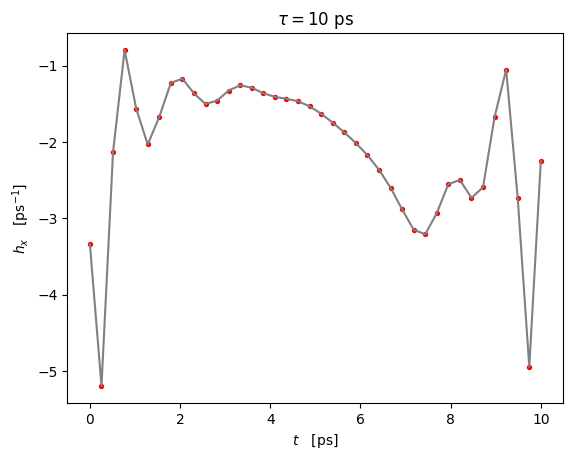

[-2.58019371 -4.40930432 -2.28677988 -0.75307098 -0.91150461 -1.30726787
 -1.20602974 -0.8442486  -0.62207104 -0.62404423 -0.70966865 -0.74272868
 -0.69268384 -0.60629968 -0.53844092 -0.5113569  -0.51474249 -0.52581969
 -0.52733135 -0.51438522 -0.49188029 -0.46804488 -0.4491251  -0.43729625
 -0.43130688 -0.42834405 -0.42578178 -0.42211129 -0.41704354 -0.41113717
 -0.40526006 -0.40014593 -0.39616024 -0.39324433 -0.39099594 -0.38881332
 -0.38606054 -0.38220858 -0.37694017 -0.370229   -0.36236192 -0.35392174
 -0.34572989 -0.33870511 -0.33366554 -0.33109081 -0.33087827 -0.33219709
 -0.33354413 -0.33308935 -0.32933385 -0.32192706 -0.31231098 -0.30374269
 -0.3003555  -0.3053046  -0.31858525 -0.33565879 -0.34808495 -0.34680536
 -0.32748319 -0.2956045  -0.26780046 -0.26600837 -0.30377293 -0.36995806
 -0.42292646 -0.41025465 -0.31434249 -0.19548444 -0.18261485 -0.37603604
 -0.69261282 -0.81607263 -0.48325844  0.00904224 -0.27584314 -1.86991203
 -2.99447361 -1.00081828]


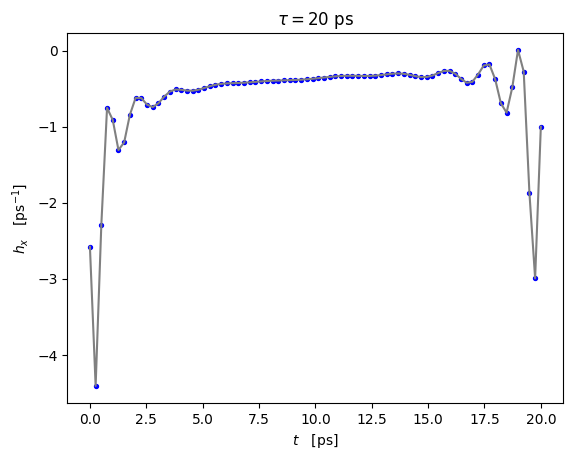

[-2.50528829 -4.29302206 -2.20481706 -0.67233237 -0.84560788 -1.29085745
 -1.24772951 -0.91942057 -0.69233809 -0.66745972 -0.73194997 -0.76640157
 -0.73700206 -0.67403992 -0.61767755 -0.58676639 -0.5776809  -0.57727809
 -0.57455873 -0.56522459 -0.55061786 -0.53436248 -0.51958003 -0.50769857
 -0.49857577 -0.49123656 -0.48462067 -0.47800499 -0.47109976 -0.46396659
 -0.45683921 -0.44996436 -0.44351857 -0.43757863 -0.43213459 -0.42712209
 -0.42246087 -0.41807403 -0.41390079 -0.40990463 -0.40606565 -0.40237304
 -0.39882062 -0.39540394 -0.39211467 -0.38893938 -0.38586563 -0.38287683
 -0.37995536 -0.37708819 -0.37426163 -0.37146677 -0.36869835 -0.3659504
 -0.3632231  -0.36051845 -0.35783749 -0.35518656 -0.35257021 -0.34999292
 -0.34746186 -0.34497995 -0.34255236 -0.34018874 -0.33789214 -0.33565912
 -0.33349807 -0.33141433 -0.3294085  -0.32748375 -0.32563272 -0.32385608
 -0.32215844 -0.32053771 -0.31899005 -0.31750748 -0.31608569 -0.31471973
 -0.3133971  -0.3121185  -0.31087617 -0.30965533 -0.

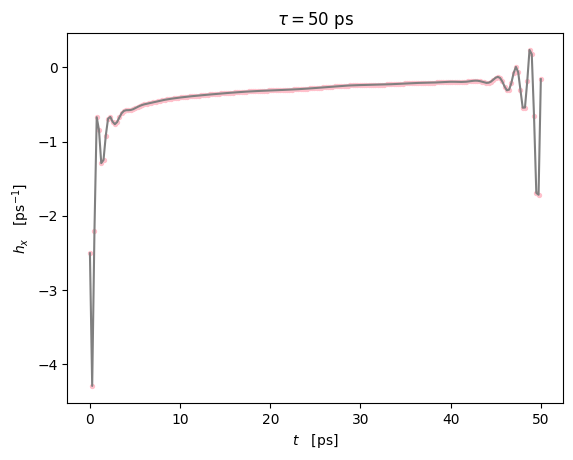

[-2.9355567  -4.64088154 -2.00214444 -0.71728198 -1.20748586 -1.50207717
 -1.17275445 -0.800187   -0.72973153 -0.83134268 -0.88249774 -0.81976825
 -0.71460302 -0.64701485 -0.63623561 -0.65341933 -0.66308953 -0.64993922
 -0.62028497 -0.58904657 -0.56725617 -0.55729696 -0.55504232 -0.55450565
 -0.55141142 -0.54443557 -0.53460912 -0.52393522 -0.51416897 -0.50623101
 -0.50017803 -0.49550715 -0.491541   -0.48771444 -0.48370803 -0.47943457
 -0.47497291 -0.47047807 -0.46609099 -0.46190986 -0.45798453 -0.4543069
 -0.45083748 -0.44753474 -0.44435387 -0.44125501 -0.43821887 -0.43523446
 -0.43229488 -0.42940352 -0.42656211 -0.42377136 -0.4210353  -0.41835161
 -0.41571805 -0.41313335 -0.41059129 -0.40809032 -0.40562817 -0.40319979
 -0.40080397 -0.39843904 -0.39610092 -0.39379208 -0.39151352 -0.38926058
 -0.38702815 -0.38482131 -0.38264083 -0.38048178 -0.37835576 -0.37624719
 -0.37415512 -0.37208538 -0.37003687 -0.36801237 -0.3660157  -0.36405073
 -0.36208157 -0.36012263 -0.35819481 -0.3563026  -0.

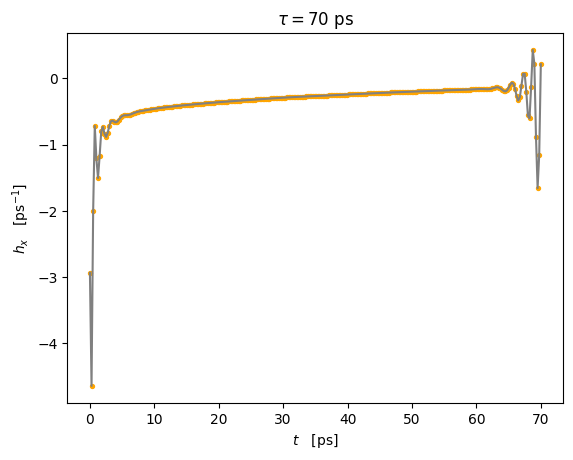

[-3.1206142  -4.64674297 -1.75049895 -0.71296134 -1.31012853 -1.50699471
 -1.11535439 -0.79075557 -0.79569227 -0.91972592 -0.93771507 -0.83335956
 -0.71769234 -0.67233794 -0.6918589  -0.72467102 -0.73064548 -0.70464209
 -0.66556073 -0.63427051 -0.62003005 -0.61976814 -0.62458783 -0.62660212
 -0.62238961 -0.61283743 -0.60104442 -0.59008052 -0.58167727 -0.57604273
 -0.57236877 -0.56951896 -0.5665529  -0.56296939 -0.5587003  -0.55394695
 -0.54901165 -0.54417096 -0.53958687 -0.53530972 -0.53131692 -0.52753049
 -0.52386221 -0.5202507  -0.51665479 -0.5130538  -0.50945311 -0.5058679
 -0.50231193 -0.4988012  -0.49534622 -0.49194912 -0.48861325 -0.48533588
 -0.48211067 -0.4789345  -0.47580124 -0.47270764 -0.46965304 -0.46663351
 -0.46364773 -0.46069788 -0.45778018 -0.45489415 -0.45204287 -0.44922688
 -0.44643652 -0.4436781  -0.4409546  -0.43825733 -0.43560531 -0.4329797
 -0.43037583 -0.42780241 -0.42525782 -0.42274702 -0.42027466 -0.4178474
 -0.41543221 -0.41303764 -0.410682   -0.40836981 -0.40

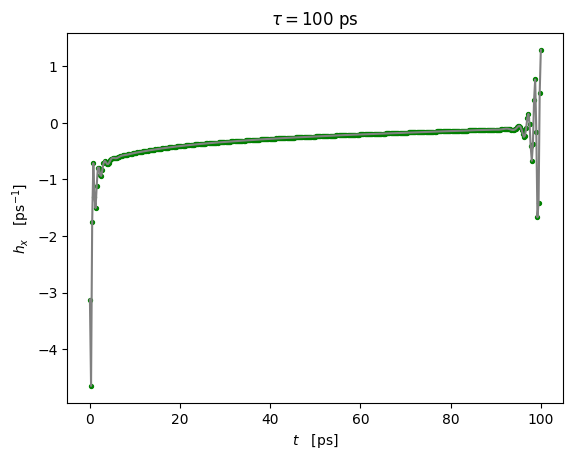

In [10]:
cs=['red','blue','pink','orange','green']
controlfigs_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}
for i,t_prot in enumerate([10,20,50,70,100]):
    opt_res=opt_dict[t_prot]
    plt.title(r'$\tau={0}$ ps'.format(t_prot))
    plt.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    plt.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    plt.xlabel(r'$t \quad[\text{ps}]$')
    plt.ylabel(r'$h_x \quad[\text{ps}^{-1}]$')
    print(opt_res.x)
    plt.show()
    

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/3166474854.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


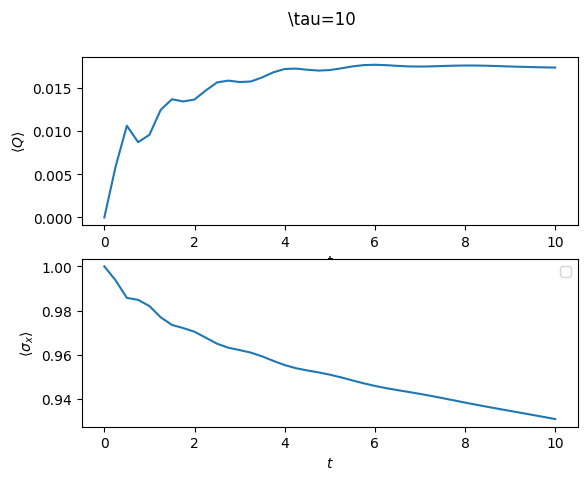

[[0.49999765+1.31093598e-13j 0.46543526-1.72649984e-13j]
 [0.46543526-1.99327068e-13j 0.49999765-1.30365687e-13j]]


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/3166474854.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


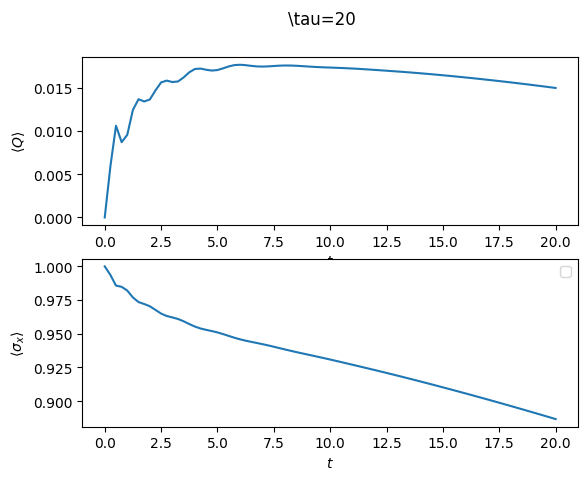

[[0.49999376+9.44747048e-13j 0.44334995-4.00793955e-13j]
 [0.44334995-1.47409300e-13j 0.49999376-8.70847990e-13j]]


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/3166474854.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


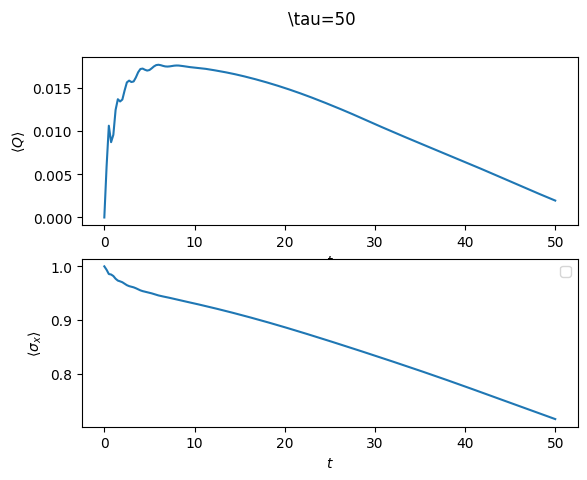

[[0.49997686+4.89360093e-13j 0.35782749+8.33062708e-13j]
 [0.35782749+1.93639485e-13j 0.49997686-7.75534022e-15j]]


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/3166474854.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


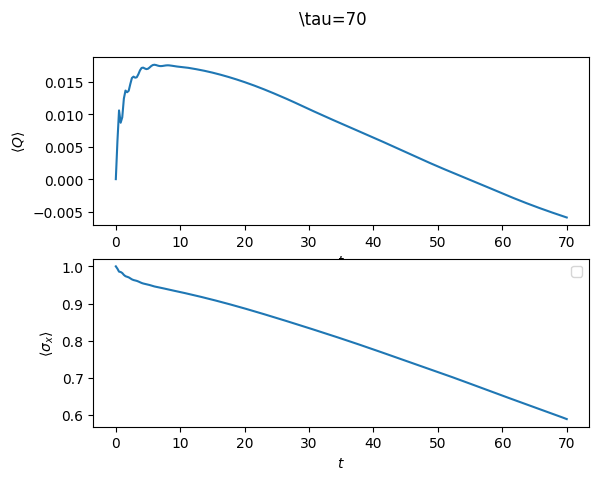

[[0.49996257-1.28162379e-12j 0.29452946+1.04712556e-12j]
 [0.29452946+1.67823953e-13j 0.49996257+2.21455739e-12j]]


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_949/3166474854.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


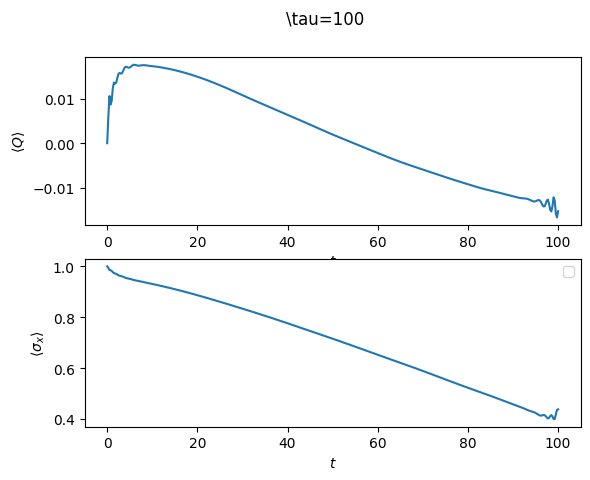

[[0.49993834-1.81112665e-12j 0.21907168-3.38734945e-13j]
 [0.21907168-1.58940492e-13j 0.49993834+2.81583484e-12j]]


In [ ]:
opt_grad_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

for t_prot in [10,20,50,70,100]:
    fig,axs=plt.subplots(2)
    fig.suptitle(r'$\tau={0}$'.format(t_prot))

    num_steps=int(t_prot/process_tensor_varcf.dt)

    opt_parameters = np.vstack((opt_res))
    opt_parameters = reshapedparas = [i for i in (optimization_result.x.reshape((-1,num_params))).tolist() for j in range(2)]
    opt_parameters=np.array(opt_parameters)

    grad_res_opt = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamics=grad_res_opt['dynamics']
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)

    grad_res_opt_cf = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_varcf],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamicscf=grad_res_opt_cf['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

    opt_grad_dict[t_prot]=grad_res_opt_cf

    axs[0].plot(t,heats,label=t_prot)
    axs[0].set_xlabel(r'$t$')
    axs[0].set_ylabel(r'$\langle Q \rangle$')
    axs[1].plot(t,s_x)
    axs[1].set_xlabel(r'$t$')
    axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
    plt.legend()
    plt.show()
    print(dynamics.states[-1])

# Landauer erasure in the strong coupling regime inheritly requires a Non-Markovian control in order 

In [12]:
print(oqupy.operators.SPIN_DM['x+'])


[[0.5, 0.5], [0.5, 0.5]]


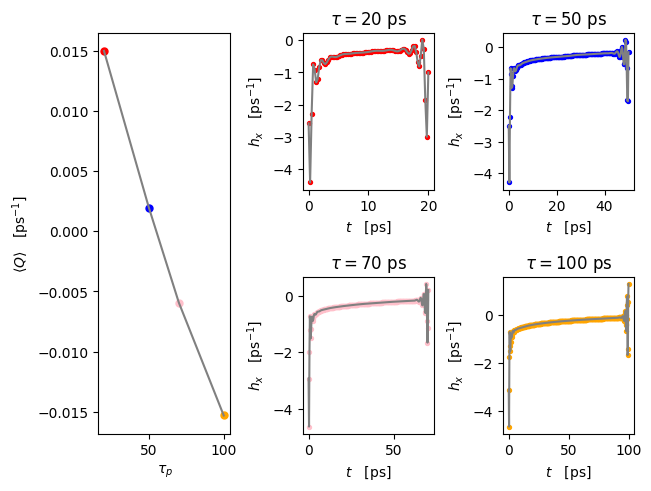

In [13]:
import matplotlib.gridspec as gridspec


cs=['red','blue','pink','orange','green']
final_heats=[]

fig = plt.figure(constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Large plot on the left
ax1 = fig.add_subplot(gs[:, 0])

# 2x2 grid on the right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

graphpositions={20:ax2,
                50:ax3,
                70:ax4,
                100:ax5}

u=0.01
for i,t_prot in enumerate([20,50,70,100]):
    dynamicscf=opt_grad_dict[t_prot]['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u
    final_heats.append(heats[-1])
    ax1.scatter(t_prot,heats[-1],s=25,c=cs[i])
    axs=graphpositions[t_prot]
    opt_res=opt_dict[t_prot]
    axs.set_title(r'$\tau={0}$ ps'.format(t_prot))
    axs.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    axs.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    axs.set_xlabel(r'$t \quad[\text{ps}]$')
    axs.set_ylabel(r'$h_x \quad[\text{ps}^{-1}]$')


ax1.plot([20,50,70,100],final_heats,c='gray')
ax1.set_xlabel(r' $\tau_p$ ')
ax1.set_ylabel(r'$\langle Q \rangle \quad[\text{ps}^{-1}]$')
plt.show()

# course graining
# 

In [40]:
from scipy.optimize import curve_fit

def control_analytic(t, T, alpha, omega, sigma):
    """
    Analytic bang-bang-inspired control function.

    Parameters:
    - t     : float or ndarray, time(s) at which to evaluate the control
    - T     : float, total duration of the protocol
    - alpha : float, slope of the linear ramp in the middle
    - omega : float, frequency of oscillations at the edges
    - sigma : float, width of the envelope for oscillations (smaller = more localized)

    Returns:
    - u(t) : control value(s) at time t
    """
    t = np.asarray(t)
    A_t = np.exp(-((t - T/2) / sigma) ** 4)
    B_t = alpha * t
    return A_t * np.sin(omega * t) + B_t

t_prot=20
t=np.linspace(0,t_prot,len(opt_dict[t_prot].x))
popt,pcov=curve_fit(control_analytic,t,opt_dict[t_prot].x)

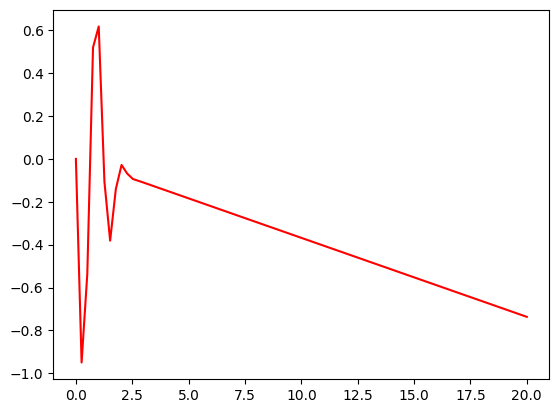

In [41]:
plt.plot(t ,control_analytic(t, *popt), 'r-')

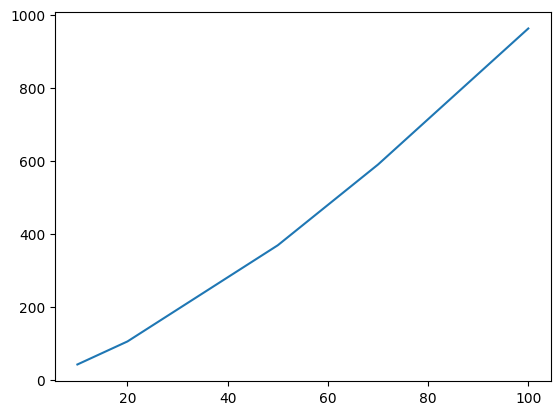

In [43]:
plt.plot([10,20,50,70,100],opt_runtimes)

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_layo'

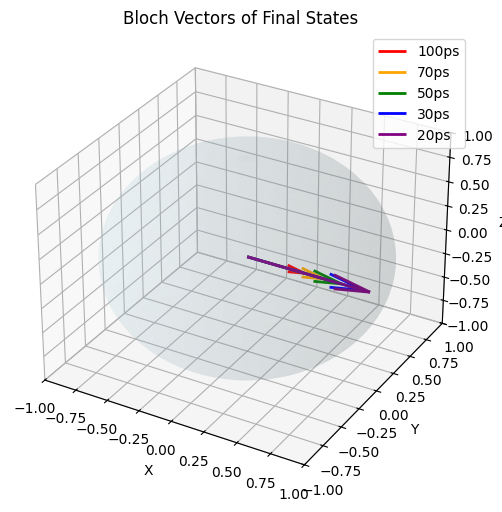

In [14]:
# Your density matrices (from optimization at different protocol durations)
raw_matrices = [
    [[0.49993834-1.81547801e-12j, 0.21907168-3.35903693e-13j],
     [0.21907168-1.57720087e-13j, 0.49993834+2.84295891e-12j]],
    
    [[0.49996257-1.28189709e-12j, 0.29452946+1.04866756e-12j],
     [0.29452946+1.69373917e-13j, 0.49996257+2.24014378e-12j]],
    
    [[0.49997686+4.85736961e-13j, 0.35782749+8.38832097e-13j],
     [0.35782749+1.84762999e-13j, 0.49997686+9.60219898e-15j]],
    
    [[0.49999376+9.51108247e-13j, 0.44334995-3.82043604e-13j],
     [0.44334995-1.66495163e-13j, 0.49999376-8.72581356e-13j]],
    
    [[0.49999765+1.34933699e-13j, 0.46543526-1.63254889e-13j],
     [0.46543526-2.09906191e-13j, 0.49999765-1.29624009e-13j]]
]

# Convert to numpy arrays
density_matrices = [np.array(rho) for rho in raw_matrices]

# Compute Bloch vectors
bloch_vectors = []
for rho in density_matrices:
    x = 2 * np.real(rho[0, 1])
    y = 2 * np.imag(rho[1, 0])
    z = np.real(rho[0, 0] - rho[1, 1])
    bloch_vectors.append([x, y, z])

bloch_vectors = np.array(bloch_vectors)

# Plot on Bloch sphere using matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Draw Bloch sphere
u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
x_sphere = np.cos(u)*np.sin(v)
y_sphere = np.sin(u)*np.sin(v)
z_sphere = np.cos(v)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.1)

# Plot Bloch vectors
colors = ['r', 'orange', 'green', 'blue', 'purple']
labels = ['100ps', '70ps', '50ps', '30ps', '20ps']

for vec, color, label in zip(bloch_vectors, colors, labels):
    ax.quiver(0, 0, 0, *vec, color=color, label=label, linewidth=2)

# Formatting
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Bloch Vectors of Final States")
ax.legend()
plt.tight_layo

In [36]:
commasthere=""
for entry in opt_smallest.split():
    commasthere+=entry+","
print(commasthere)

-1.79159916,-3.92662526,-3.4670617,-1.93037757,-1.00053274,-0.91835613,-1.19042718,-1.38241826,-1.34587385,-1.15293756,-0.94271072,-0.80775444,-0.76573477,-0.78617467,-0.82597821,-0.85373202,-0.85630807,-0.83538066,-0.80167338,-0.76656224,-0.73774203,-0.71797507,-0.70556516,-0.69707282,-0.68852854,-0.67667504,-0.65996158,-0.63779923,-0.61238529,-0.58578327,-0.55918491,-0.53461253,-0.51290479,-0.49481753,-0.48061371,-0.47014007,-0.46319279,-0.45881817,-0.4557765,-0.4535156,-0.45213722,-0.45123861,-0.45039811,-0.44958037,-0.44867018,-0.4477923,-0.44700885,-0.44638431,-0.44597115,-0.44566835,-0.4454296,-0.44503085,-0.44430416,-0.44306209,-0.44105546,-0.43819359,-0.43436084,-0.42975375,-0.42461645,-0.41947937,-0.41520307,-0.41252506,-0.41065382,-0.40954334,-0.41050658,-0.41310463,-0.41621315,-0.41825664,-0.41710025,-0.41109266,-0.39930699,-0.38207452,-0.36260638,-0.3439808,-0.3297082,-0.32498348,-0.33395258,-0.35812035,-0.39414754,-0.43386225,-0.46479598,-0.47350682,-0.45104378,-0.39814099